In [35]:
# ============================================================
#  1: IMPORT LIBRARIES
# ============================================================

import os
import time
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [36]:
# ============================================================
#  2: CONFIGURATION
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20

DATA_PATH = "dataset/wine_quality_merged.csv"
RESULTS_DIR = "results"

# Create result folders
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "confusion_matrices"), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "classification_reports"), exist_ok=True)

print("Configuration completed.")
print("Random State:", RANDOM_STATE)
print("Test Size:", TEST_SIZE)
print("Dataset Path:", DATA_PATH)

Configuration completed.
Random State: 42
Test Size: 0.2
Dataset Path: dataset/wine_quality_merged.csv


In [37]:
# ============================================================
# 3: CHECK DATASET PATH
# ============================================================

if os.path.exists(DATA_PATH):
    print("Dataset found successfully.")
else:
    print("Dataset NOT found.")
    print("Check that the CSV file is inside the 'dataset' folder.")

Dataset found successfully.


In [38]:
# ============================================================
#  4: LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [39]:
# ============================================================
# 5: BASIC DATASET INFORMATION
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(6497, 13)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                        str
dtype: object

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality               

In [40]:
# ============================================================
#  6: REMOVE DUPLICATES
# ============================================================

duplicates_before = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

duplicates_after = df.duplicated().sum()

print("Duplicates before removal:", duplicates_before)
print("Duplicates after removal:", duplicates_after)
print("Dataset shape after removing duplicates:", df.shape)

Duplicates before removal: 1177
Duplicates after removal: 0
Dataset shape after removing duplicates: (5320, 13)


Wine Quality Class Distribution:
quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64


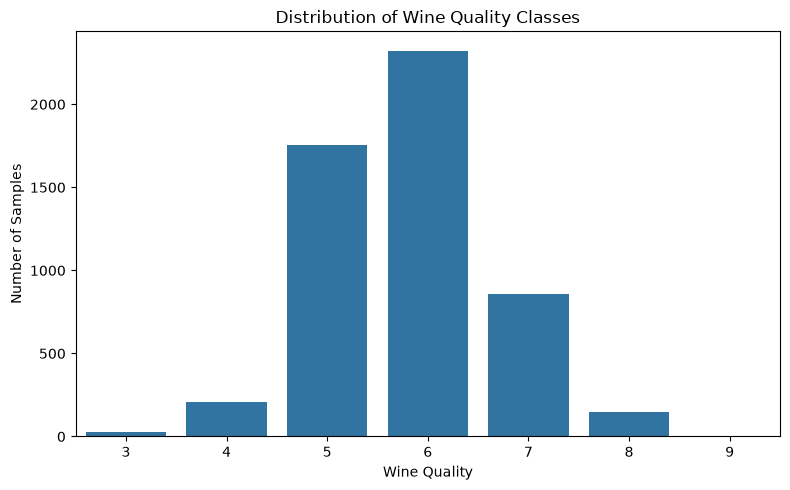

In [41]:
# ============================================================
#  7: TARGET CLASS DISTRIBUTION
# ============================================================

print("Wine Quality Class Distribution:")
print(df["quality"].value_counts().sort_index())

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality",
    order=sorted(df["quality"].unique())
)

plt.title("Distribution of Wine Quality Classes")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Samples")
plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR, "class_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [42]:
# ============================================================
#  8: SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("quality", axis=1)
y = df["quality"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("quality")

Feature shape: (5320, 12)
Target shape: (5320,)

Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type']

Target:
quality


In [43]:
# ============================================================
#  9: DEFINE FEATURE TYPES
# ============================================================

categorical_features = ["type"]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Categorical Features:
['type']


In [44]:
# ============================================================
#  10: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training samples: 4256
Testing samples: 1064

Training class distribution:
quality
3      24
4     165
5    1402
6    1858
7     685
8     118
9       4
Name: count, dtype: int64

Testing class distribution:
quality
3      6
4     41
5    350
6    465
7    171
8     30
9      1
Name: count, dtype: int64


In [45]:
# ============================================================
#  11: ONE-HOT ENCODER
# ============================================================

try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

print("OneHotEncoder created successfully.")

OneHotEncoder created successfully.


In [46]:
# ============================================================
#  12: PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", encoder, categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [47]:
# ============================================================
# 13: t-SNE FEATURE SPACE VISUALIZATION
# ============================================================

print("Preparing data for t-SNE...")

# Preprocess the complete feature dataset only for visualization
X_processed = preprocessor.fit_transform(X)

print("Processed feature shape:", X_processed.shape)

# Create t-SNE model
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto"
)

print("Running t-SNE...")
X_tsne = tsne.fit_transform(X_processed)

print("t-SNE completed.")
print("t-SNE output shape:", X_tsne.shape)

Preparing data for t-SNE...
Processed feature shape: (5320, 13)
Running t-SNE...
t-SNE completed.
t-SNE output shape: (5320, 2)


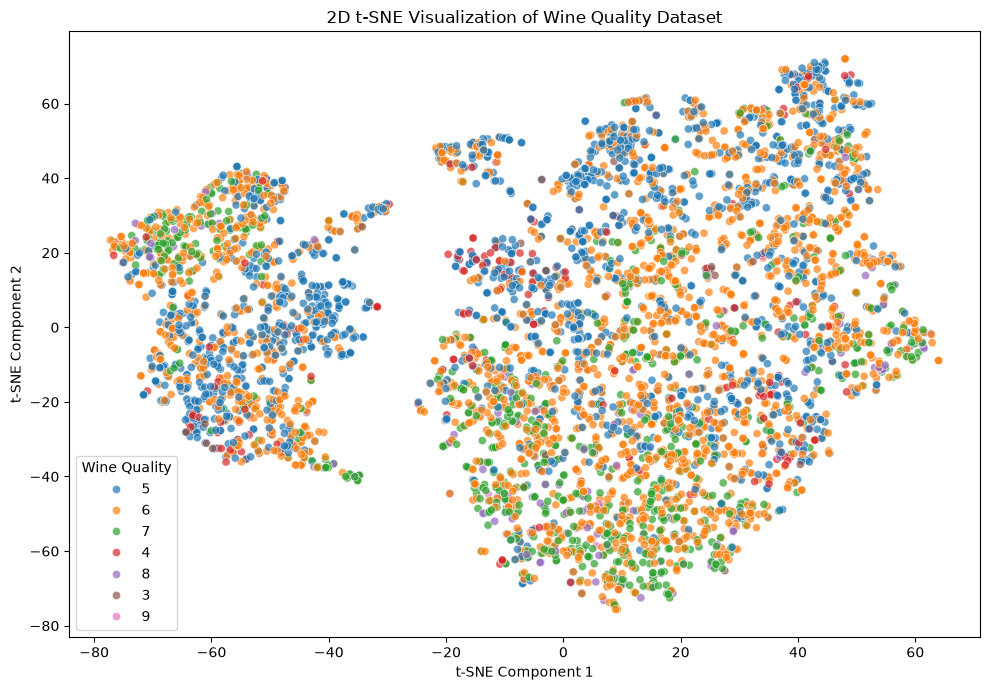

In [48]:
# ============================================================
# 14: PLOT t-SNE
# ============================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y.astype(str),
    palette="tab10",
    s=35,
    alpha=0.7
)

plt.title("2D t-SNE Visualization of Wine Quality Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Wine Quality")

plt.tight_layout()

plt.savefig(
    "results/tsne_plot.png",
    dpi=300
)

plt.show()

In [49]:
# ============================================================
#  15: DEFINE SVM MODELS
# ============================================================

svm_models = [
    (
        "SVM - Linear",
        SVC(
            kernel="linear",
            C=1.0
        )
    ),

    (
        "SVM - Polynomial",
        SVC(
            kernel="poly",
            degree=3,
            C=1.0,
            gamma="scale"
        )
    ),

    (
        "SVM - RBF",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale"
        )
    )
]

print("SVM models:")
for name, model in svm_models:
    print("-", name)

SVM models:
- SVM - Linear
- SVM - Polynomial
- SVM - RBF


In [50]:
# ============================================================
#  16: DEFINE DECISION TREE EXPERIMENTS
# ============================================================

max_depth_values = [3, 5, 10, None]
min_samples_split_values = [2, 10]

tree_models = []

for depth in max_depth_values:
    for min_split in min_samples_split_values:

        model_name = (
            f"Decision Tree - depth={depth}, "
            f"min_split={min_split}"
        )

        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=min_split,
            random_state=RANDOM_STATE
        )

        tree_models.append(
            (model_name, model)
        )

print("Decision Tree configurations:")

for name, model in tree_models:
    print("-", name)

print("\nTotal Decision Tree models:", len(tree_models))

Decision Tree configurations:
- Decision Tree - depth=3, min_split=2
- Decision Tree - depth=3, min_split=10
- Decision Tree - depth=5, min_split=2
- Decision Tree - depth=5, min_split=10
- Decision Tree - depth=10, min_split=2
- Decision Tree - depth=10, min_split=10
- Decision Tree - depth=None, min_split=2
- Decision Tree - depth=None, min_split=10

Total Decision Tree models: 8


In [51]:
# ============================================================
#  17: COMBINE ALL MODELS
# ============================================================

all_models = svm_models + tree_models

print("Total models:", len(all_models))

print("\nModels to be evaluated:")

for i, (name, model) in enumerate(all_models, start=1):
    print(f"{i}. {name}")

Total models: 11

Models to be evaluated:
1. SVM - Linear
2. SVM - Polynomial
3. SVM - RBF
4. Decision Tree - depth=3, min_split=2
5. Decision Tree - depth=3, min_split=10
6. Decision Tree - depth=5, min_split=2
7. Decision Tree - depth=5, min_split=10
8. Decision Tree - depth=10, min_split=2
9. Decision Tree - depth=10, min_split=10
10. Decision Tree - depth=None, min_split=2
11. Decision Tree - depth=None, min_split=10


In [52]:
# ============================================================
# 18: MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, model):

    print("\n" + "=" * 70)
    print("Running:", model_name)
    print("=" * 70)

    # Create an independent preprocessing pipeline
    current_preprocessor = clone(preprocessor)

    # Create an independent model
    current_model = clone(model)

    # Complete pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessing", current_preprocessor),
            ("model", current_model)
        ]
    )

    # Process information
    process = psutil.Process(os.getpid())

    # Memory before training
    memory_before = process.memory_info().rss / (1024 ** 2)

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    start_train = time.perf_counter()

    pipeline.fit(X_train, y_train)

    end_train = time.perf_counter()

    training_time = end_train - start_train

    # Memory after training
    memory_after = process.memory_info().rss / (1024 ** 2)

    memory_change = memory_after - memory_before

    # --------------------------------------------------------
    # CPU SNAPSHOT
    # --------------------------------------------------------

    cpu_usage = psutil.cpu_percent(interval=0.2)

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    start_prediction = time.perf_counter()

    y_pred = pipeline.predict(X_test)

    end_prediction = time.perf_counter()

    prediction_time = end_prediction - start_prediction

    # --------------------------------------------------------
    # PERFORMANCE METRICS
    # --------------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # --------------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=sorted(y.unique())
    )

    # Clean filename
    safe_name = (
        model_name
        .replace(" ", "_")
        .replace("=", "")
        .replace(",", "")
    )

    # Save confusion matrix
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=sorted(y.unique()),
        yticklabels=sorted(y.unique())
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            RESULTS_DIR,
            "confusion_matrices",
            f"{safe_name}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # --------------------------------------------------------
    # CLASSIFICATION REPORT
    # --------------------------------------------------------

    report = classification_report(
        y_test,
        y_pred,
        zero_division=0
    )

    report_path = os.path.join(
        RESULTS_DIR,
        "classification_reports",
        f"{safe_name}.txt"
    )

    with open(report_path, "w") as file:
        file.write(f"Model: {model_name}\n")
        file.write("=" * 70 + "\n\n")
        file.write(report)

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-score       : {f1:.4f}")
    print(f"Training Time  : {training_time:.4f} seconds")
    print(f"Prediction Time: {prediction_time:.4f} seconds")
    print(f"Memory Before  : {memory_before:.2f} MB")
    print(f"Memory After   : {memory_after:.2f} MB")
    print(f"Memory Change  : {memory_change:.2f} MB")
    print(f"CPU Utilization: {cpu_usage:.2f}%")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time,
        "Memory Before (MB)": memory_before,
        "Memory After (MB)": memory_after,
        "Memory Change (MB)": memory_change,
        "CPU Utilization (%)": cpu_usage
    }


Running: SVM - Linear


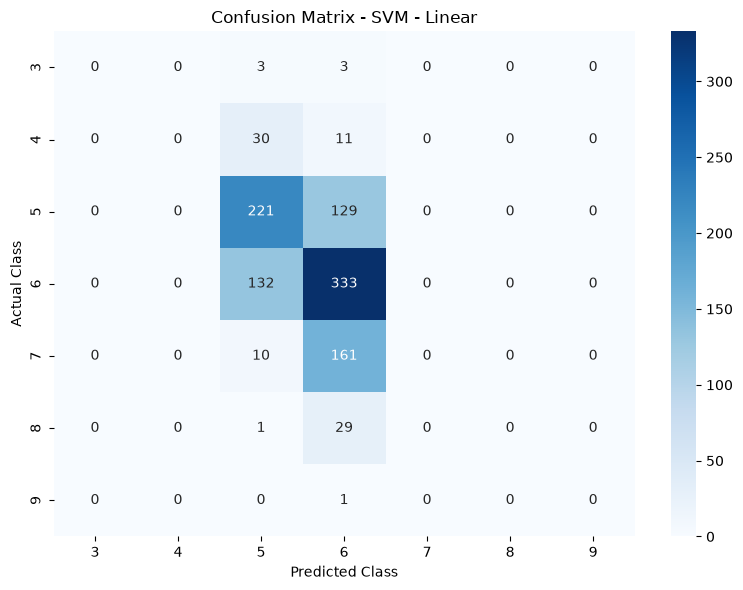

Accuracy       : 0.5207
Precision      : 0.4013
Recall         : 0.5207
F1-score       : 0.4518
Training Time  : 1.0272 seconds
Prediction Time: 0.1573 seconds
Memory Before  : 241.23 MB
Memory After   : 240.62 MB
Memory Change  : -0.61 MB
CPU Utilization: 4.50%

Running: SVM - Polynomial


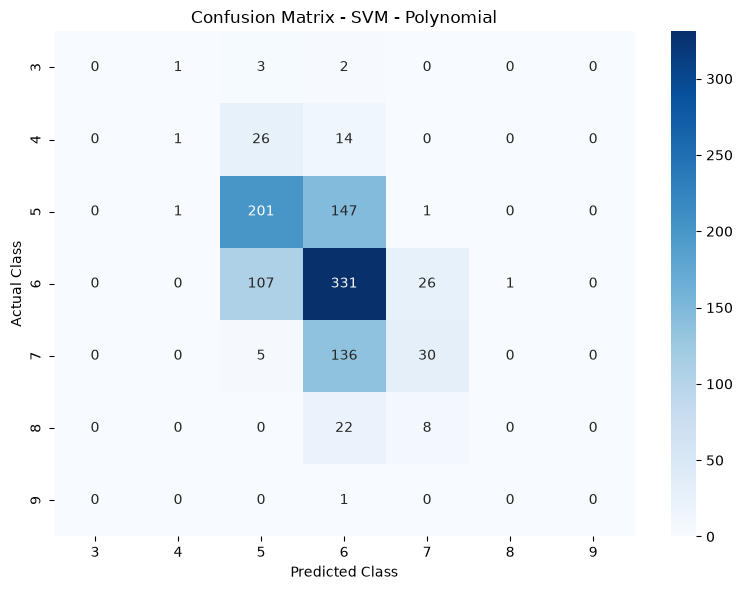

Accuracy       : 0.5291
Precision      : 0.5019
Recall         : 0.5291
F1-score       : 0.4925
Training Time  : 1.0161 seconds
Prediction Time: 0.1517 seconds
Memory Before  : 243.37 MB
Memory After   : 242.64 MB
Memory Change  : -0.73 MB
CPU Utilization: 7.10%

Running: SVM - RBF


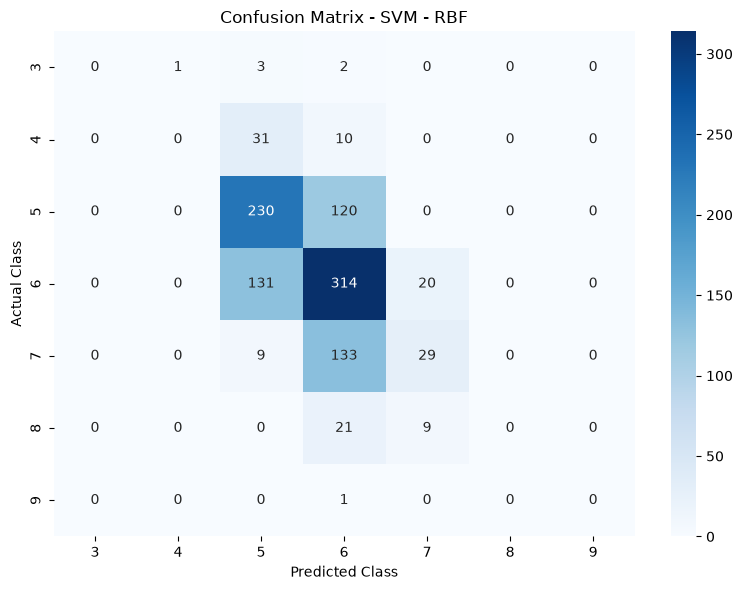

Accuracy       : 0.5385
Precision      : 0.4960
Recall         : 0.5385
F1-score       : 0.4989
Training Time  : 1.0356 seconds
Prediction Time: 0.4548 seconds
Memory Before  : 244.80 MB
Memory After   : 245.32 MB
Memory Change  : 0.51 MB
CPU Utilization: 3.90%

Running: Decision Tree - depth=3, min_split=2


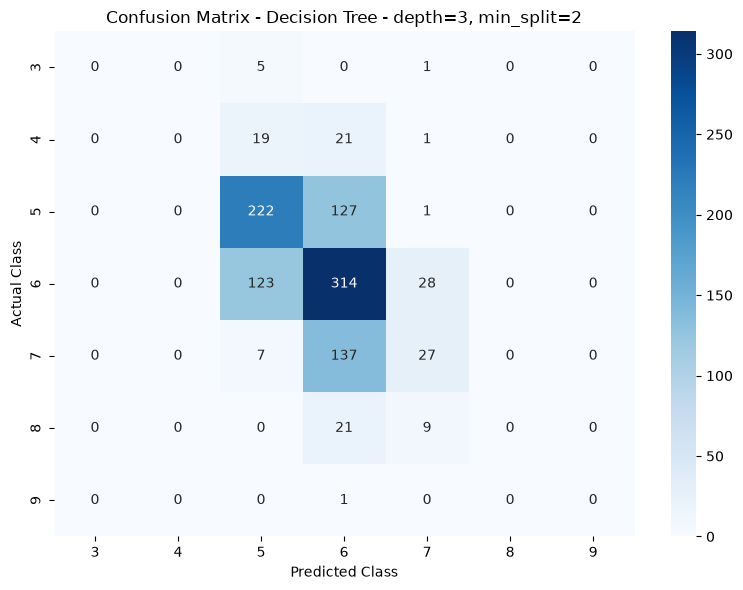

Accuracy       : 0.5291
Precision      : 0.4800
Recall         : 0.5291
F1-score       : 0.4904
Training Time  : 0.0266 seconds
Prediction Time: 0.0075 seconds
Memory Before  : 247.66 MB
Memory After   : 248.11 MB
Memory Change  : 0.45 MB
CPU Utilization: 3.10%

Running: Decision Tree - depth=3, min_split=10


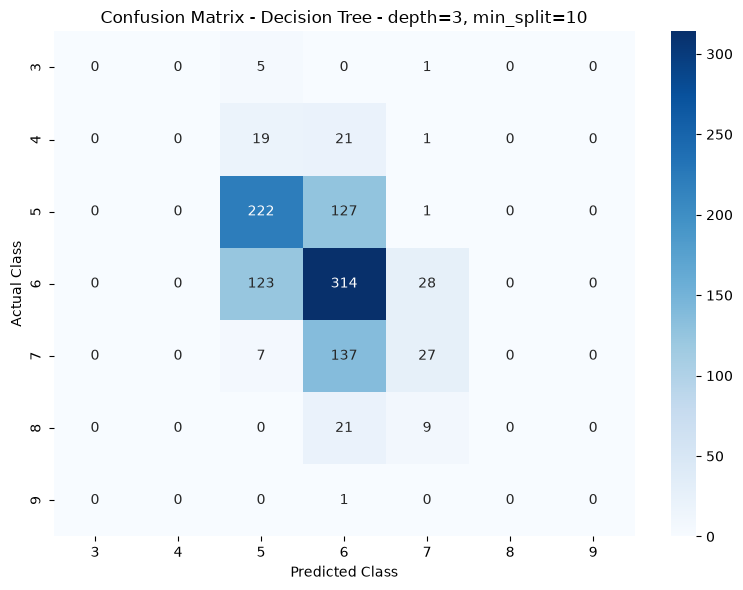

Accuracy       : 0.5291
Precision      : 0.4800
Recall         : 0.5291
F1-score       : 0.4904
Training Time  : 0.0270 seconds
Prediction Time: 0.0090 seconds
Memory Before  : 249.80 MB
Memory After   : 249.80 MB
Memory Change  : 0.00 MB
CPU Utilization: 2.90%

Running: Decision Tree - depth=5, min_split=2


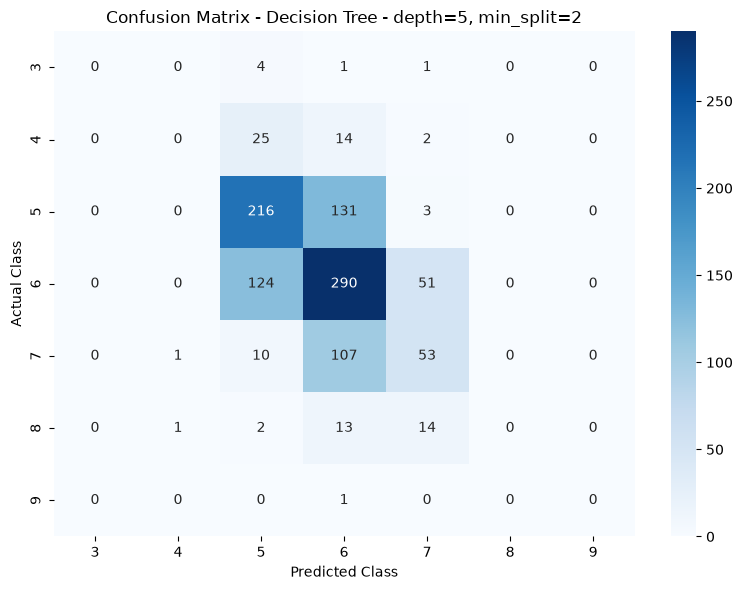

Accuracy       : 0.5254
Precision      : 0.4827
Recall         : 0.5254
F1-score       : 0.5002
Training Time  : 0.0349 seconds
Prediction Time: 0.0079 seconds
Memory Before  : 251.49 MB
Memory After   : 251.49 MB
Memory Change  : 0.00 MB
CPU Utilization: 1.40%

Running: Decision Tree - depth=5, min_split=10


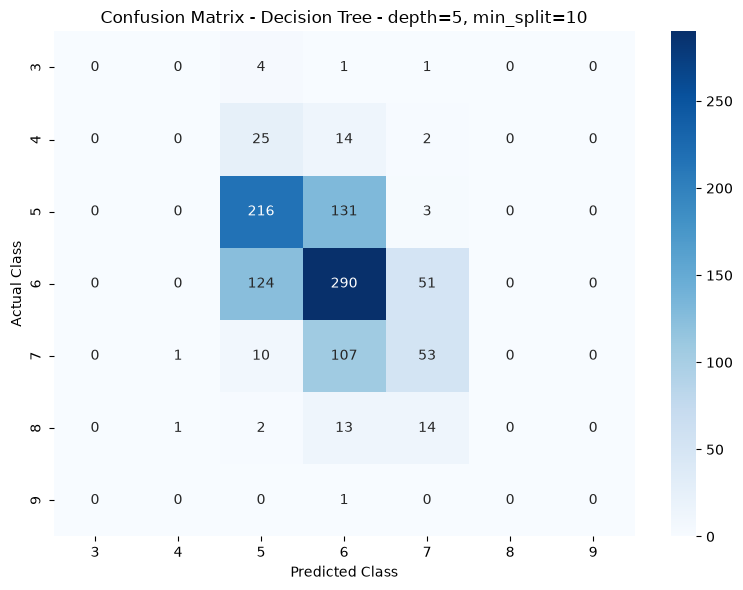

Accuracy       : 0.5254
Precision      : 0.4827
Recall         : 0.5254
F1-score       : 0.5002
Training Time  : 0.0354 seconds
Prediction Time: 0.0073 seconds
Memory Before  : 237.48 MB
Memory After   : 237.73 MB
Memory Change  : 0.25 MB
CPU Utilization: 3.80%

Running: Decision Tree - depth=10, min_split=2


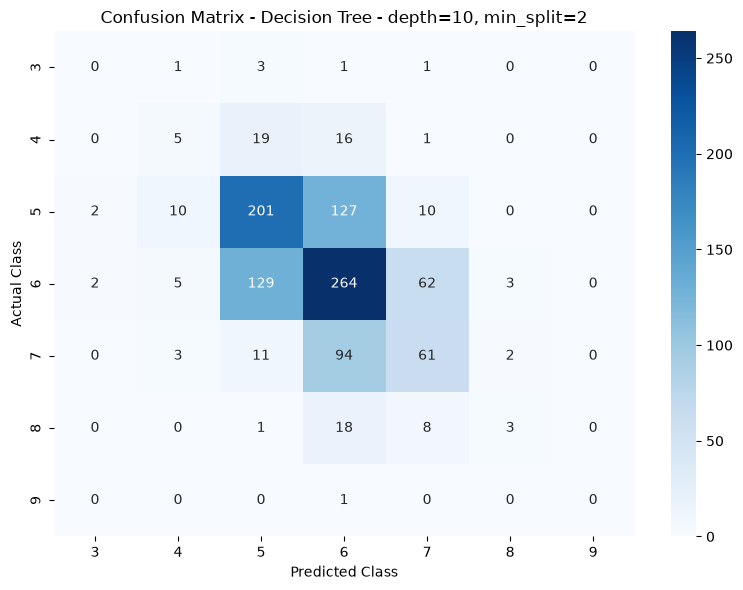

Accuracy       : 0.5019
Precision      : 0.4903
Recall         : 0.5019
F1-score       : 0.4921
Training Time  : 0.0584 seconds
Prediction Time: 0.0079 seconds
Memory Before  : 239.40 MB
Memory After   : 239.40 MB
Memory Change  : 0.00 MB
CPU Utilization: 1.50%

Running: Decision Tree - depth=10, min_split=10


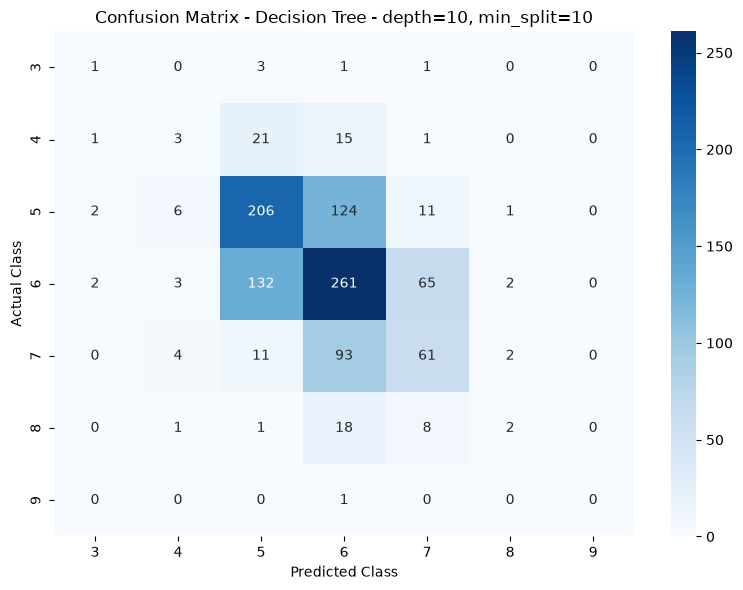

Accuracy       : 0.5019
Precision      : 0.4860
Recall         : 0.5019
F1-score       : 0.4901
Training Time  : 0.0556 seconds
Prediction Time: 0.0090 seconds
Memory Before  : 241.08 MB
Memory After   : 241.08 MB
Memory Change  : 0.00 MB
CPU Utilization: 3.80%

Running: Decision Tree - depth=None, min_split=2


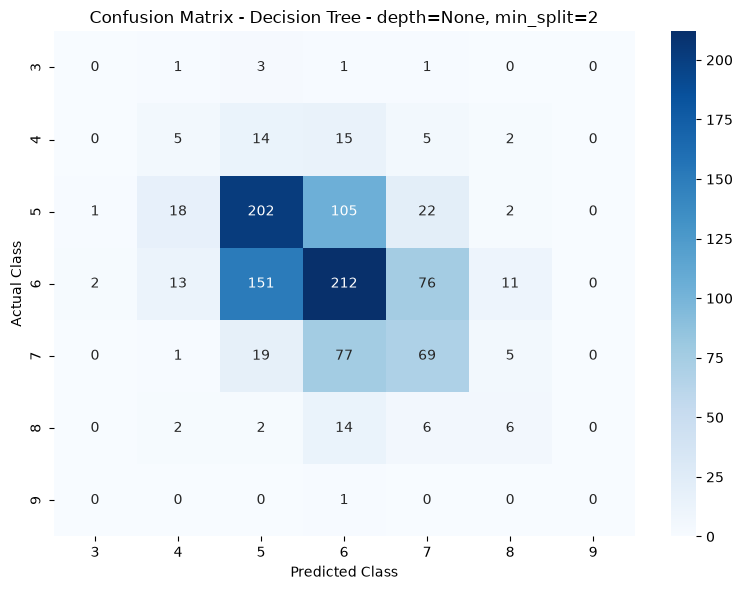

Accuracy       : 0.4643
Precision      : 0.4612
Recall         : 0.4643
F1-score       : 0.4617
Training Time  : 0.0758 seconds
Prediction Time: 0.0081 seconds
Memory Before  : 242.75 MB
Memory After   : 243.24 MB
Memory Change  : 0.48 MB
CPU Utilization: 4.40%

Running: Decision Tree - depth=None, min_split=10


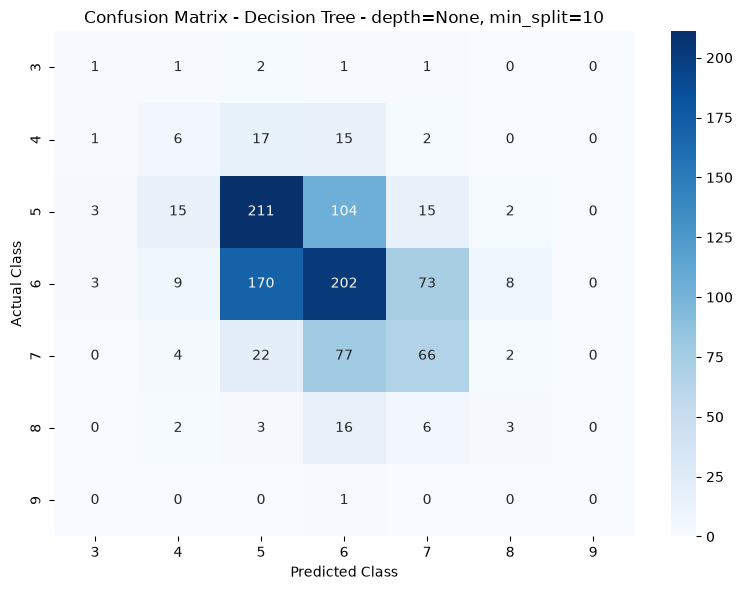

Accuracy       : 0.4596
Precision      : 0.4532
Recall         : 0.4596
F1-score       : 0.4535
Training Time  : 0.0674 seconds
Prediction Time: 0.0080 seconds
Memory Before  : 244.94 MB
Memory After   : 244.94 MB
Memory Change  : 0.00 MB
CPU Utilization: 1.90%

ALL MODELS COMPLETED
Total experiment execution time: 17.8109 seconds


In [53]:
# ============================================================
# 19: RUN ALL MODELS
# ============================================================

results = []

total_start_time = time.perf_counter()

for model_name, model in all_models:

    result = evaluate_model(
        model_name,
        model
    )

    results.append(result)

total_end_time = time.perf_counter()

total_execution_time = (
    total_end_time - total_start_time
)

print("\n" + "=" * 70)
print("ALL MODELS COMPLETED")
print("=" * 70)

print(
    f"Total experiment execution time: "
    f"{total_execution_time:.4f} seconds"
)

In [54]:
# ============================================================
#  20: FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("Final Results:")
display(results_df)

Final Results:


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s),Memory Before (MB),Memory After (MB),Memory Change (MB),CPU Utilization (%)
0,SVM - Linear,0.520677,0.401304,0.520677,0.451760,1.027196,0.157286,241.226562,240.621094,-0.605469,4.5
1,SVM - Polynomial,0.529135,0.501876,0.529135,0.492483,1.016068,0.151662,243.371094,242.644531,-0.726562,7.1
2,SVM - RBF,0.538534,0.495961,0.538534,0.498851,1.035580,0.454758,244.804688,245.316406,0.511719,3.9
3,"Decision Tree - depth=3, min_split=2",0.529135,0.479963,0.529135,0.490360,0.026593,0.007478,247.664062,248.109375,0.445312,3.1
4,"Decision Tree - depth=3, min_split=10",0.529135,0.479963,0.529135,0.490360,0.026961,0.008966,249.796875,249.796875,0.000000,2.9
5,"Decision Tree - depth=5, min_split=2",0.525376,0.482720,0.525376,0.500168,0.034875,0.007905,251.492188,251.492188,0.000000,1.4
6,"Decision Tree - depth=5, min_split=10",0.525376,0.482720,0.525376,0.500168,0.035382,0.007283,237.476562,237.726562,0.250000,3.8
7,"Decision Tree - depth=10, min_split=2",0.501880,0.490253,0.501880,0.492057,0.058436,0.007884,239.402344,239.402344,0.000000,1.5
8,"Decision Tree - depth=10, min_split=10",0.501880,0.486020,0.501880,0.490084,0.055593,0.009033,241.078125,241.078125,0.000000,3.8
9,"Decision Tree - depth=None, min_split=2",0.464286,0.461218,0.464286,0.461715,0.075781,0.008066,242.753906,243.238281,0.484375,4.4


In [55]:
# ============================================================
# 21: SAVE FINAL RESULTS TABLE
# ============================================================

results_path = os.path.join(
    RESULTS_DIR,
    "final_model_comparison.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("Final results saved to:")
print(results_path)

Final results saved to:
results\final_model_comparison.csv


<Figure size 1400x700 with 0 Axes>

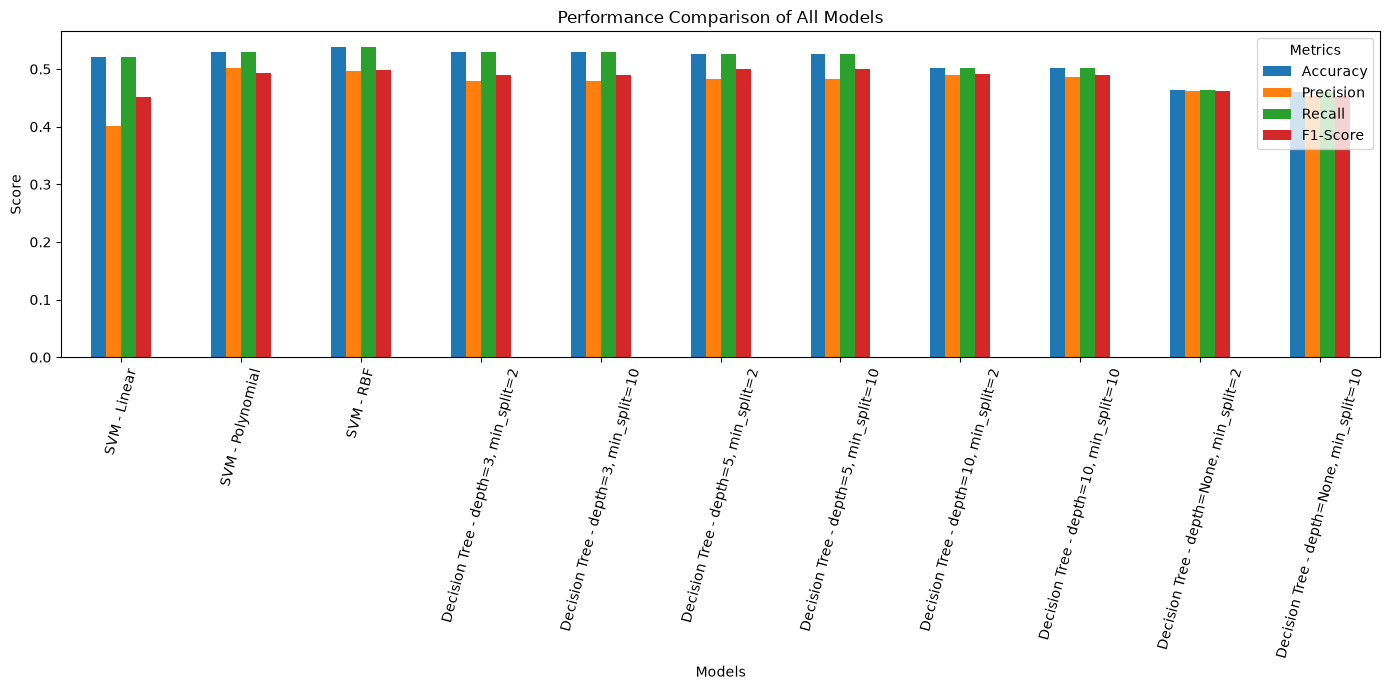

In [56]:
# ============================================================
#  22: PERFORMANCE COMPARISON GRAPH
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

plot_df = results_df[
    ["Model"] + metrics
].copy()

plot_df = plot_df.set_index("Model")

plt.figure(figsize=(14, 7))

plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Performance Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=75)
plt.legend(title="Metrics")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "model_performance_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

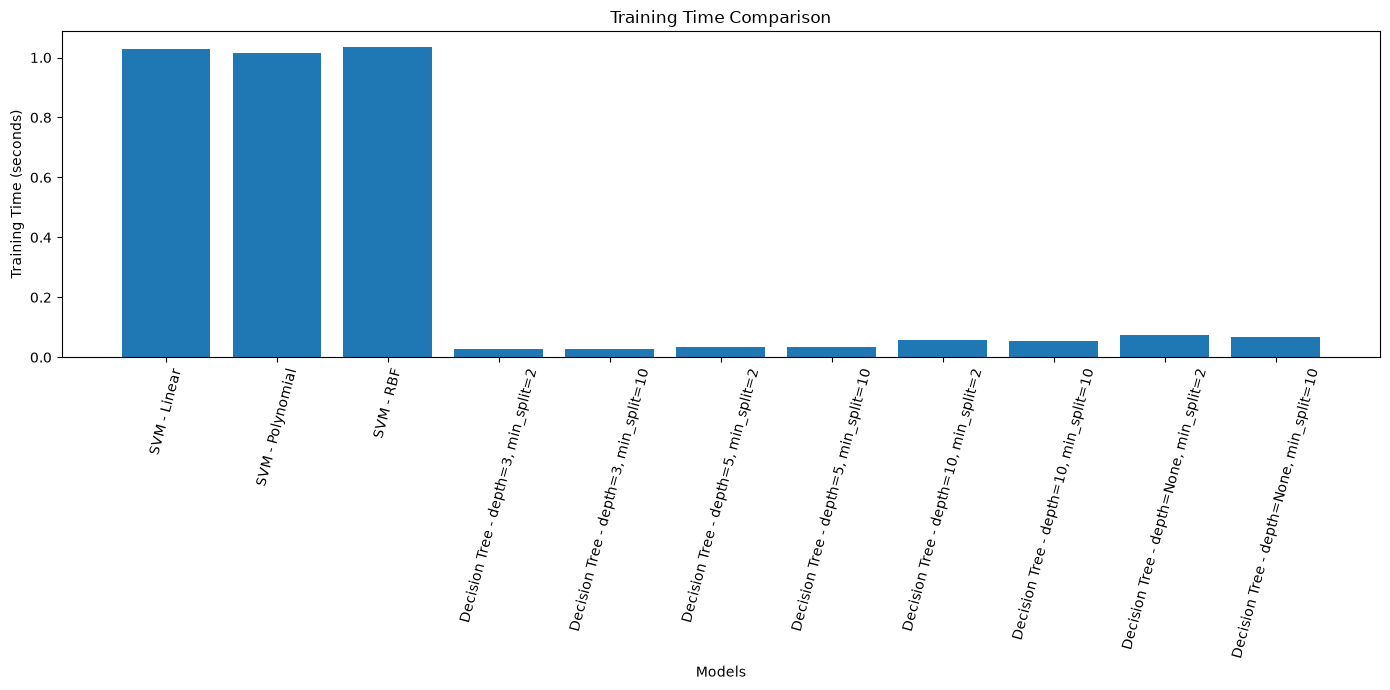

In [57]:
# ============================================================
#  23: TRAINING TIME COMPARISON
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Model"],
    results_df["Training Time (s)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=75)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "training_time_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

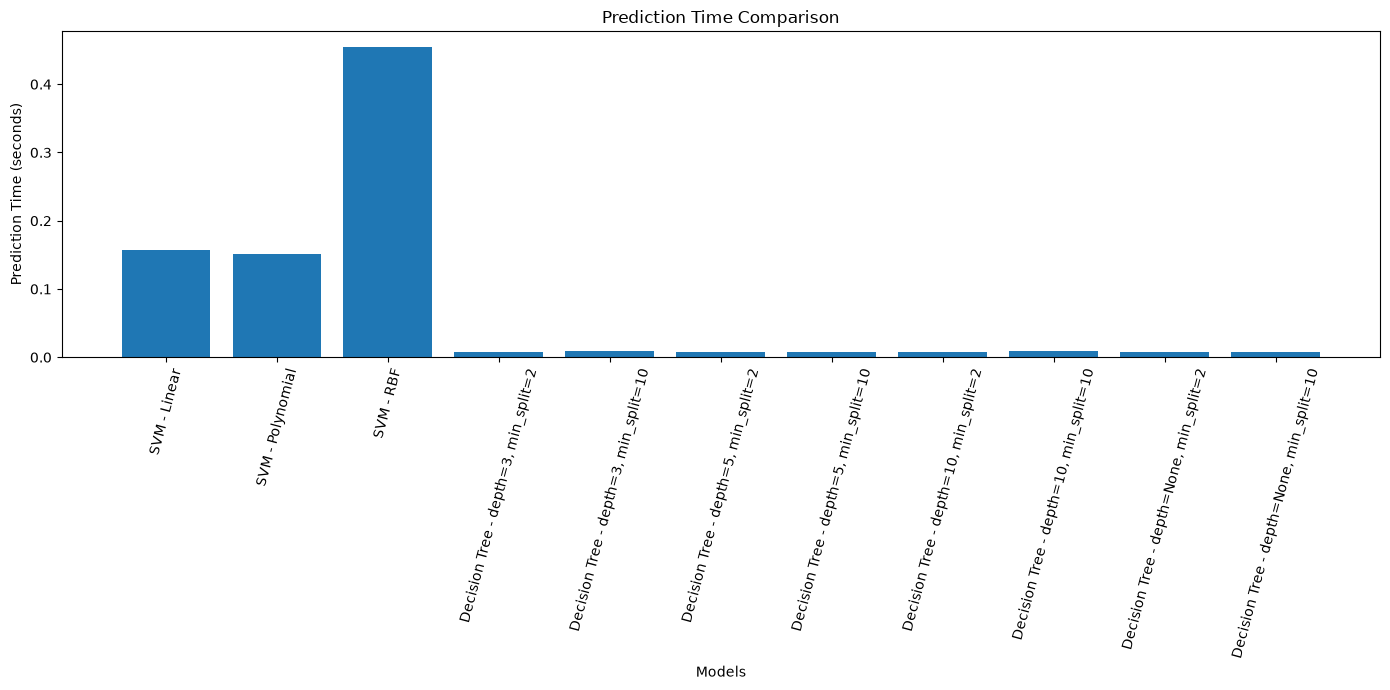

In [58]:
# ============================================================
# 24: PREDICTION TIME COMPARISON
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Model"],
    results_df["Prediction Time (s)"]
)

plt.title("Prediction Time Comparison")
plt.xlabel("Models")
plt.ylabel("Prediction Time (seconds)")
plt.xticks(rotation=75)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "prediction_time_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

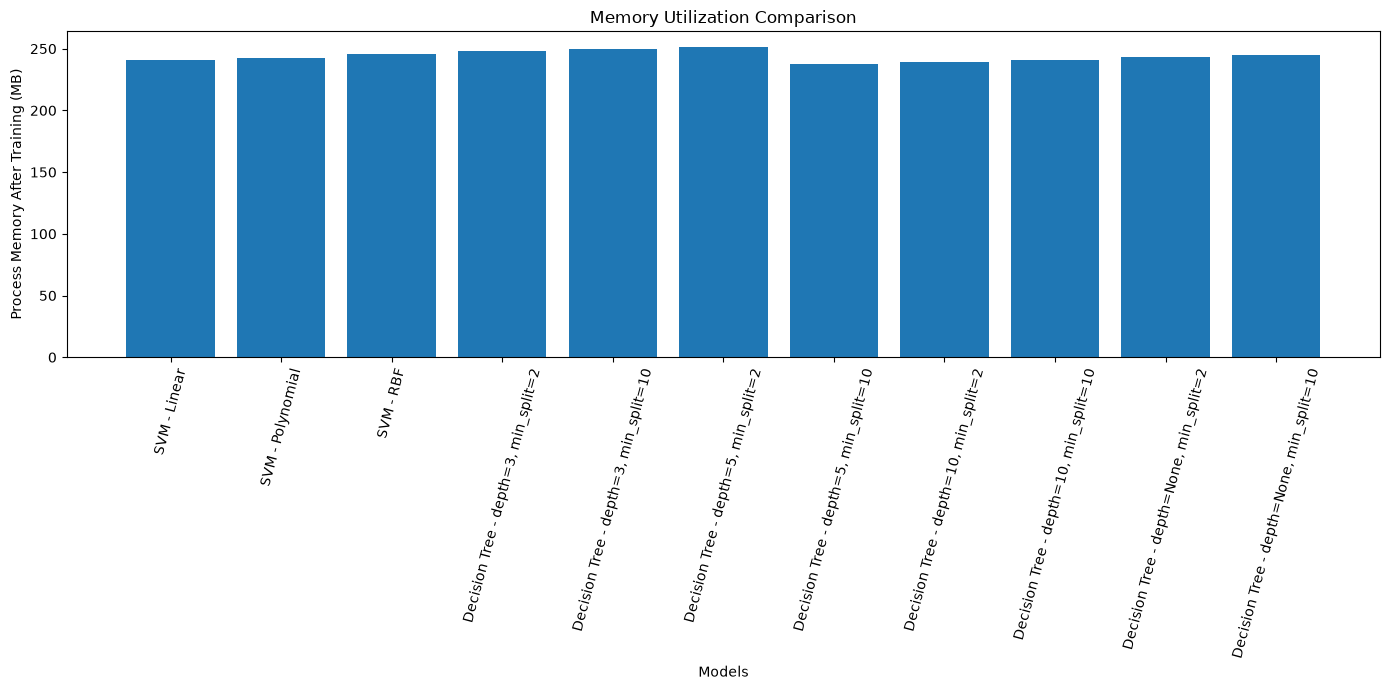

In [59]:
# ============================================================
# 25: MEMORY UTILIZATION COMPARISON
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Model"],
    results_df["Memory After (MB)"]
)

plt.title("Memory Utilization Comparison")
plt.xlabel("Models")
plt.ylabel("Process Memory After Training (MB)")
plt.xticks(rotation=75)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "memory_utilization_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

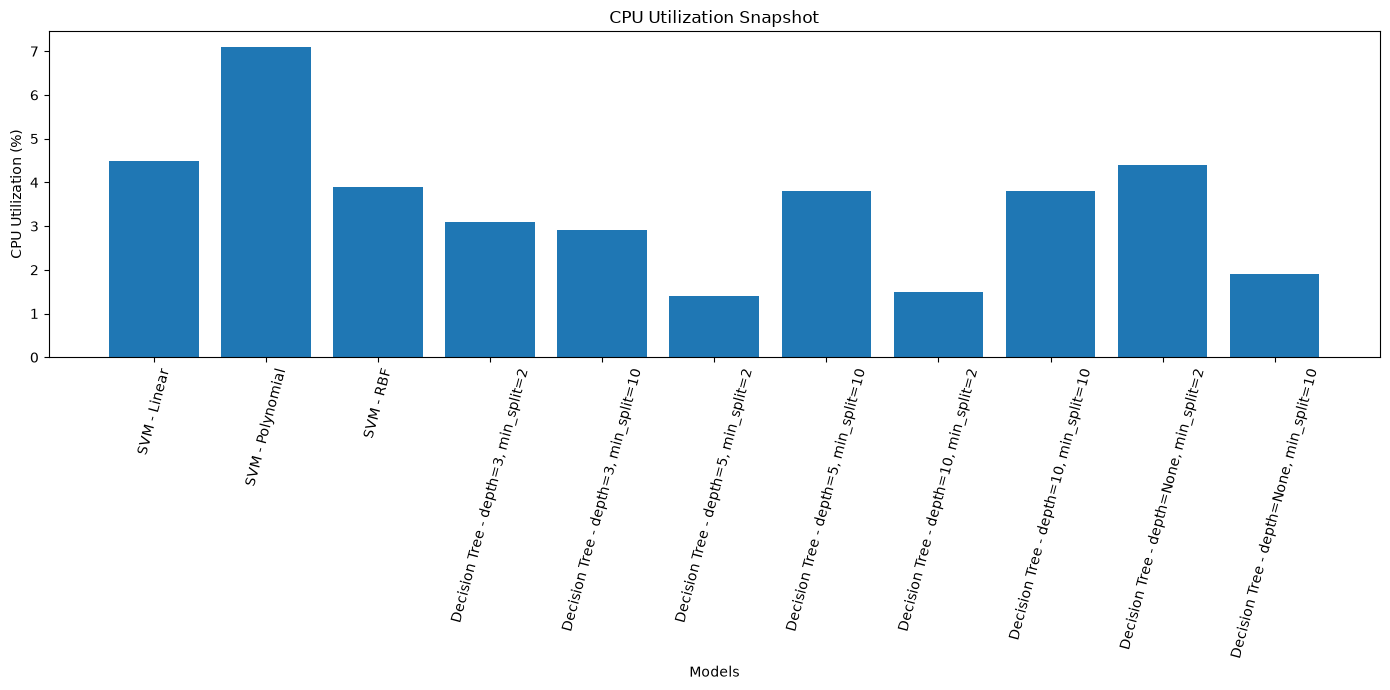

In [60]:
# ============================================================
#  26: CPU Utilization Comparison
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Model"],
    results_df["CPU Utilization (%)"]
)

plt.title("CPU Utilization Snapshot")
plt.xlabel("Models")
plt.ylabel("CPU Utilization (%)")
plt.xticks(rotation=75)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "cpu_utilization_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [61]:
# ============================================================
#  27: TOTAL EXECUTION TIME
# ============================================================

print("=" * 60)
print("COMPUTATIONAL RESOURCE SUMMARY")
print("=" * 60)

print(
    f"Total execution time for all models: "
    f"{total_execution_time:.4f} seconds"
)

print(
    f"Total execution time in minutes: "
    f"{total_execution_time / 60:.2f} minutes"
)

COMPUTATIONAL RESOURCE SUMMARY
Total execution time for all models: 17.8109 seconds
Total execution time in minutes: 0.30 minutes


In [62]:
# ============================================================
#  28: SAVE EXPERIMENT SUMMARY
# ============================================================

summary_path = os.path.join(
    RESULTS_DIR,
    "experiment_summary.txt"
)

with open(summary_path, "w") as file:

    file.write("AI/ML CLASSIFICATION ASSIGNMENT\n")
    file.write("=" * 70 + "\n\n")

    file.write("Dataset: Wine Quality\n")
    file.write(f"Original dataset shape: 6497 rows x 13 columns\n")
    file.write(
        f"Final dataset shape after duplicate removal: "
        f"{df.shape[0]} rows x {df.shape[1]} columns\n\n"
    )

    file.write("Preprocessing:\n")
    file.write("- Numerical features: StandardScaler\n")
    file.write("- Categorical feature: OneHotEncoder\n")
    file.write("- Duplicate rows removed before train-test split\n")
    file.write("- Train/Test split: 80/20\n")
    file.write("- Stratified splitting used\n\n")

    file.write("Models:\n")

    for model_name, model in all_models:
        file.write(f"- {model_name}\n")

    file.write("\nEvaluation Metrics:\n")
    file.write("- Accuracy\n")
    file.write("- Weighted Precision\n")
    file.write("- Weighted Recall\n")
    file.write("- Weighted F1-score\n")
    file.write("- Confusion Matrix\n")
    file.write("- Training Time\n")
    file.write("- Prediction Time\n")
    file.write("- Memory Utilization\n")
    file.write("- CPU Utilization Snapshot\n\n")

    file.write(
        f"Total experiment execution time: "
        f"{total_execution_time:.4f} seconds\n"
    )

print("Experiment summary saved.")
print(summary_path)

Experiment summary saved.
results\experiment_summary.txt


In [63]:
# ============================================================
# 29: CLEAN PERFORMANCE TABLE
# ============================================================

clean_results = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Training Time (s)",
        "Prediction Time (s)"
    ]
].copy()

display(
    clean_results.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Training Time (s)": "{:.4f}",
        "Prediction Time (s)": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,SVM - Linear,0.5207,0.4013,0.5207,0.4518,1.0272,0.1573
1,SVM - Polynomial,0.5291,0.5019,0.5291,0.4925,1.0161,0.1517
2,SVM - RBF,0.5385,0.4960,0.5385,0.4989,1.0356,0.4548
3,"Decision Tree - depth=3, min_split=2",0.5291,0.4800,0.5291,0.4904,0.0266,0.0075
4,"Decision Tree - depth=3, min_split=10",0.5291,0.4800,0.5291,0.4904,0.0270,0.0090
5,"Decision Tree - depth=5, min_split=2",0.5254,0.4827,0.5254,0.5002,0.0349,0.0079
6,"Decision Tree - depth=5, min_split=10",0.5254,0.4827,0.5254,0.5002,0.0354,0.0073
7,"Decision Tree - depth=10, min_split=2",0.5019,0.4903,0.5019,0.4921,0.0584,0.0079
8,"Decision Tree - depth=10, min_split=10",0.5019,0.4860,0.5019,0.4901,0.0556,0.0090
9,"Decision Tree - depth=None, min_split=2",0.4643,0.4612,0.4643,0.4617,0.0758,0.0081


In [64]:
# ============================================================
# 30: SAVE CLEAN RESULTS TABLE
# ============================================================

clean_results_path = os.path.join(
    RESULTS_DIR,
    "clean_performance_table.csv"
)

clean_results.to_csv(
    clean_results_path,
    index=False
)

print("Clean performance table saved:")
print(clean_results_path)

Clean performance table saved:
results\clean_performance_table.csv


In [65]:
# ============================================================
# 31: RESOURCE UTILIZATION TABLE
# ============================================================

resource_results = results_df[
    [
        "Model",
        "Training Time (s)",
        "Prediction Time (s)",
        "Memory Before (MB)",
        "Memory After (MB)",
        "Memory Change (MB)",
        "CPU Utilization (%)"
    ]
].copy()

display(
    resource_results.style
    .format({
        "Training Time (s)": "{:.4f}",
        "Prediction Time (s)": "{:.4f}",
        "Memory Before (MB)": "{:.2f}",
        "Memory After (MB)": "{:.2f}",
        "Memory Change (MB)": "{:.2f}",
        "CPU Utilization (%)": "{:.2f}"
    })
)

,Model,Training Time (s),Prediction Time (s),Memory Before (MB),Memory After (MB),Memory Change (MB),CPU Utilization (%)
0,SVM - Linear,1.0272,0.1573,241.23,240.62,-0.61,4.50
1,SVM - Polynomial,1.0161,0.1517,243.37,242.64,-0.73,7.10
2,SVM - RBF,1.0356,0.4548,244.80,245.32,0.51,3.90
3,"Decision Tree - depth=3, min_split=2",0.0266,0.0075,247.66,248.11,0.45,3.10
4,"Decision Tree - depth=3, min_split=10",0.0270,0.0090,249.80,249.80,0.00,2.90
5,"Decision Tree - depth=5, min_split=2",0.0349,0.0079,251.49,251.49,0.00,1.40
6,"Decision Tree - depth=5, min_split=10",0.0354,0.0073,237.48,237.73,0.25,3.80
7,"Decision Tree - depth=10, min_split=2",0.0584,0.0079,239.40,239.40,0.00,1.50
8,"Decision Tree - depth=10, min_split=10",0.0556,0.0090,241.08,241.08,0.00,3.80
9,"Decision Tree - depth=None, min_split=2",0.0758,0.0081,242.75,243.24,0.48,4.40


In [66]:
# ============================================================
# 32: DISPLAY CLASSIFICATION REPORTS
# ============================================================

for model_name, model in all_models:

    safe_name = (
        model_name
        .replace(" ", "_")
        .replace("=", "")
        .replace(",", "")
    )

    report_path = os.path.join(
        RESULTS_DIR,
        "classification_reports",
        f"{safe_name}.txt"
    )

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    with open(report_path, "r") as file:
        print(file.read())


SVM - Linear
Model: SVM - Linear

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        41
           5       0.56      0.63      0.59       350
           6       0.50      0.72      0.59       465
           7       0.00      0.00      0.00       171
           8       0.00      0.00      0.00        30
           9       0.00      0.00      0.00         1

    accuracy                           0.52      1064
   macro avg       0.15      0.19      0.17      1064
weighted avg       0.40      0.52      0.45      1064


SVM - Polynomial
Model: SVM - Polynomial

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.33      0.02      0.05        41
           5       0.59      0.57      0.58       350
           6       0.51      0.71      0.59       465
           7       0.46      0.18      0.25       171


In [67]:
# ============================================================
#  33: LIST ALL GENERATED FILES
# ============================================================

print("=" * 70)
print("GENERATED RESULT FILES")
print("=" * 70)

for root, directories, files in os.walk(RESULTS_DIR):

    level = root.replace(RESULTS_DIR, "").count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = "    " * (level + 1)

    for file in files:
        print(f"{sub_indent}{file}")

GENERATED RESULT FILES
results/
    class_distribution.png
    clean_performance_table.csv
    cpu_utilization_comparison.png
    execution_time_comparison.png
    experiment_summary.txt
    final_execution_time_comparison.png
    final_model_comparison.csv
    final_model_performance_comparison.png
    memory_utilization_comparison.png
    model_comparison_results.csv
    model_performance_comparison.png
    prediction_time_comparison.png
    training_time_comparison.png
    tsne_plot.png
    classification_reports/
        Decision_Tree_-_depth10_min_split10.txt
        Decision_Tree_-_depth10_min_split2.txt
        Decision_Tree_-_depth3_min_split10.txt
        Decision_Tree_-_depth3_min_split2.txt
        Decision_Tree_-_depth5_min_split10.txt
        Decision_Tree_-_depth5_min_split2.txt
        Decision_Tree_-_depthNone_min_split10.txt
        Decision_Tree_-_depthNone_min_split2.txt
        decision_tree_-_max_depth10_min_samples_split10.txt
        decision_tree_-_max_depth10_m